In [1]:
import pathlib

import pandas as pd
import numpy as np
import torch
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout, MoleculeFDetector
from ground_truth.highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod

/home/dominik/MyStuff/bxaic2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# We also need to create a table showing ROC's, AP's and other metrics for explainers.

artifact_path = pathlib.Path("artifacts/explainability_method_tester/R2")  # R2

whitebox_to_path = {}

for directory in artifact_path.iterdir():
    if directory.is_dir():
        whitebox_to_path[directory.name] = directory

whitebox_to_positive_eval = {}

for whitebox, path in whitebox_to_path.items():
    positive_eval_path = path / "positive_explainability_results.csv"

    df = pd.read_csv(positive_eval_path)
    df.dropna(subset=["SHAP Sampling_auroc"], inplace=True)  # Drop rows where SHAP Sampling_auroc is NaN
    whitebox_to_positive_eval[whitebox] = df

In [3]:
whitebox_to_shap_wins = {}
whitebox_to_shap_fails = {}

for whitebox, df in sorted(whitebox_to_positive_eval.items(), key=lambda x: x[0]):
    shap_wins = df[df["SHAP Sampling_auroc"] == 1.0]
    shap_fails = df[df["SHAP Sampling_auroc"] < 1.0]

    whitebox_to_shap_wins[whitebox] = shap_wins
    whitebox_to_shap_fails[whitebox] = shap_fails

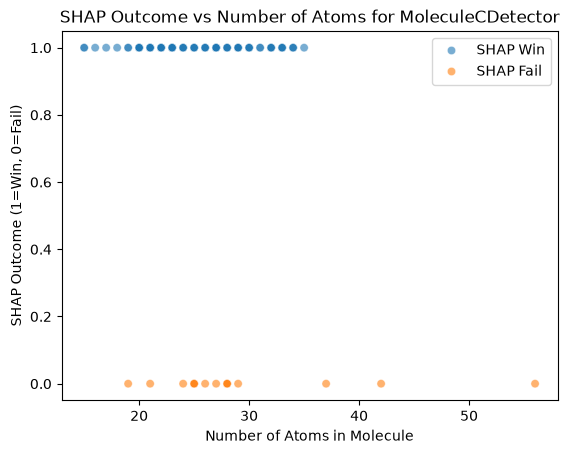

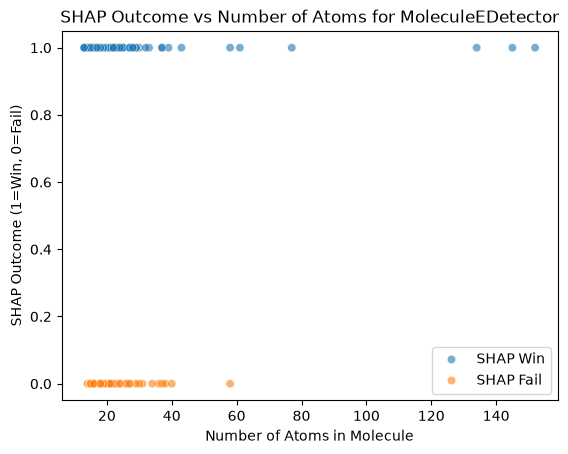

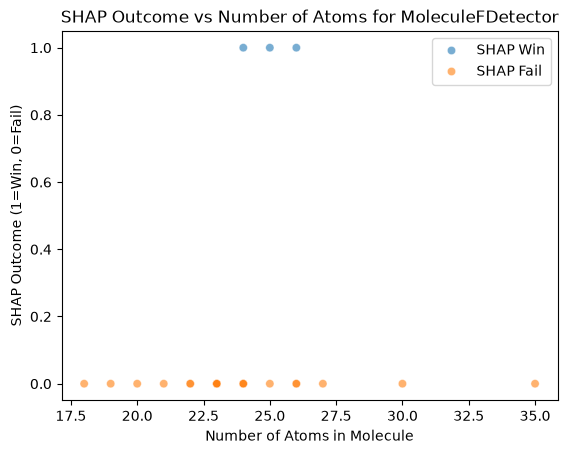

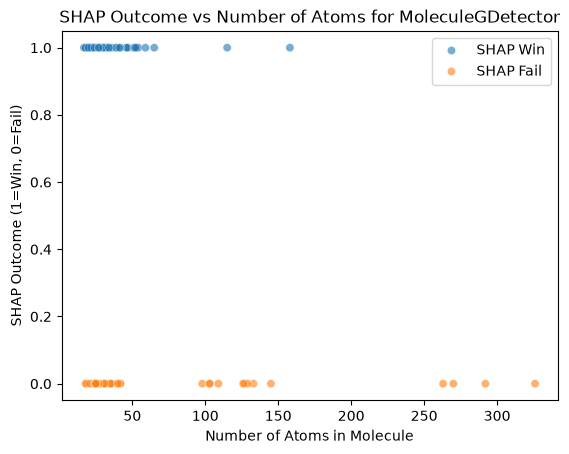

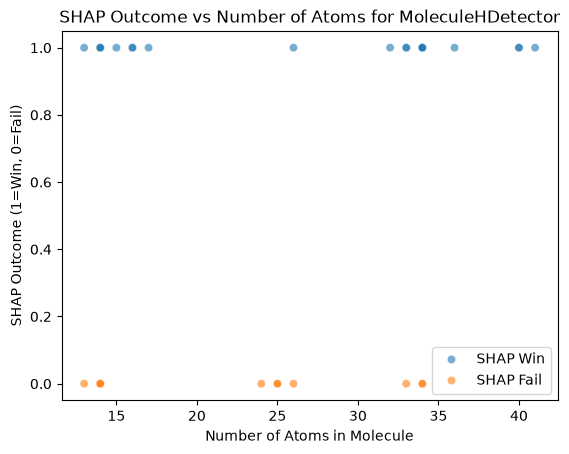

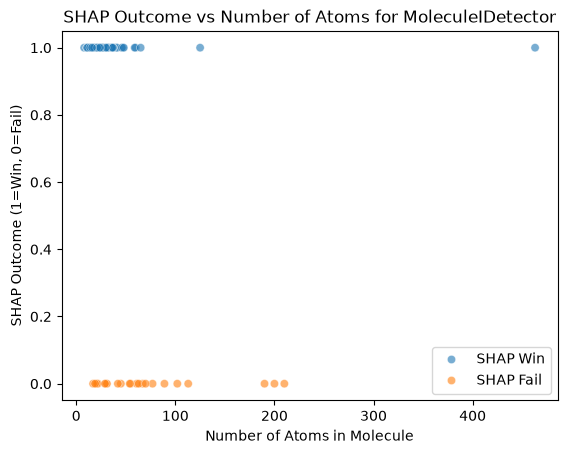

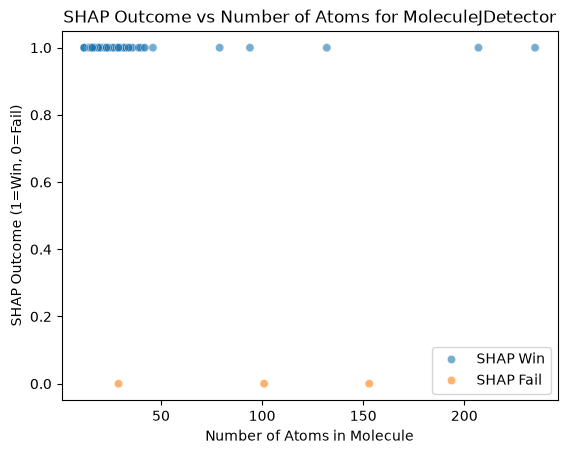

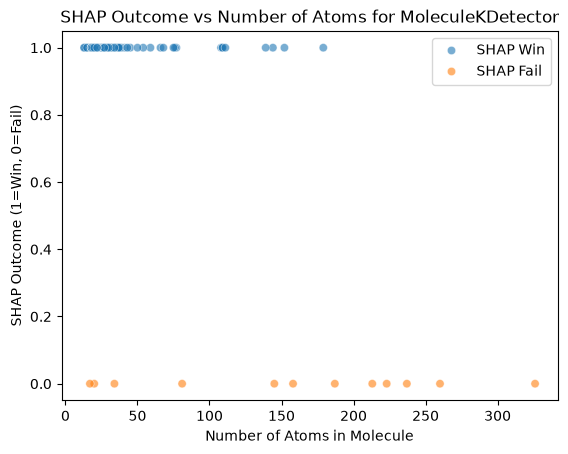

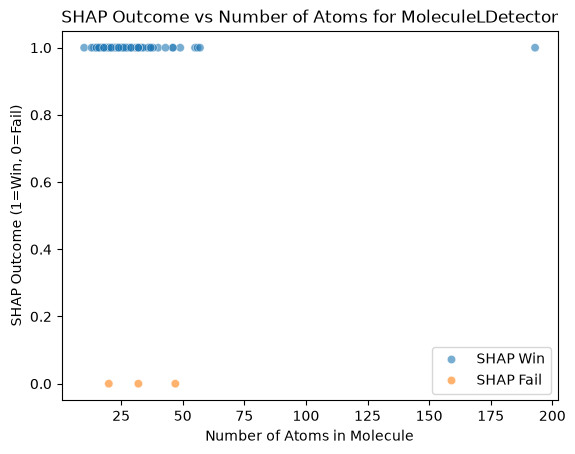

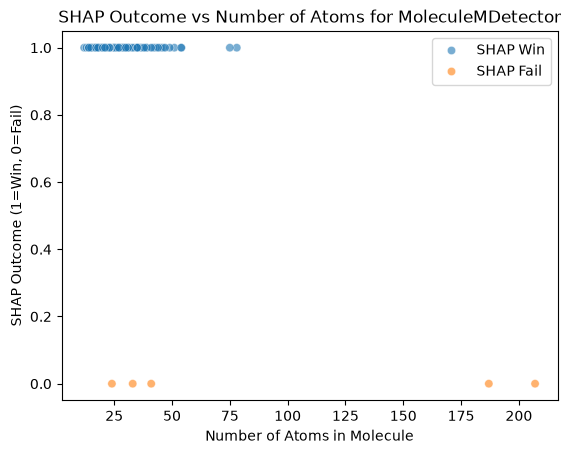

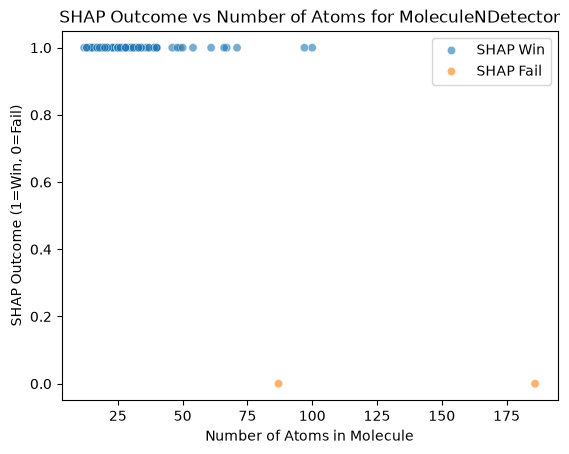

MoleculeODetector: No data for wins or fails, skipping histogram.


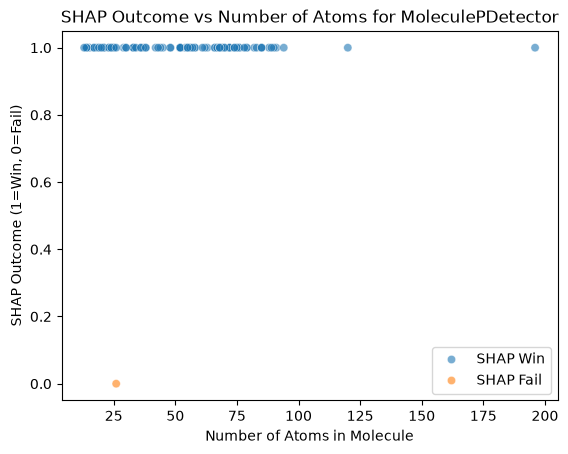

MoleculeQDetector: No data for wins or fails, skipping histogram.


In [4]:
# Q1: Is there any dependence between the number of atoms in a molecule and whether SHAP fails or not?

for whitebox, df in sorted(whitebox_to_positive_eval.items(), key=lambda x: x[0]):
    shap_wins = whitebox_to_shap_wins[whitebox]
    shap_fails = whitebox_to_shap_fails[whitebox]

    win_mols = [Chem.MolFromSmiles(smiles) for smiles in shap_wins["SMILES"]]
    fail_mols = [Chem.MolFromSmiles(smiles) for smiles in shap_fails["SMILES"]]

    shap_wins_atom_counts = [mol.GetNumAtoms() for mol in win_mols]
    shap_fails_atom_counts = [mol.GetNumAtoms() for mol in fail_mols]

    if len(shap_wins_atom_counts) == 0 or len(shap_fails_atom_counts) == 0:
        print(f"{whitebox}: No data for wins or fails, skipping histogram.")
        continue

    sns.scatterplot(
        x=shap_wins_atom_counts + shap_fails_atom_counts,
        y=[1] * len(shap_wins_atom_counts) + [0] * len(shap_fails_atom_counts),
        hue=["SHAP Win"] * len(shap_wins_atom_counts) + ["SHAP Fail"] * len(shap_fails_atom_counts),
        alpha=0.6
    )

    plt.xlabel("Number of Atoms in Molecule")
    plt.ylabel("SHAP Outcome (1=Win, 0=Fail)")
    plt.title(f"SHAP Outcome vs Number of Atoms for {whitebox}")

    plt.show()



In [5]:
whitebox_to_winrate = {}

for whitebox, df in sorted(whitebox_to_positive_eval.items(), key=lambda x: x[0]):
    shap_wins = whitebox_to_shap_wins[whitebox]
    shap_fails = whitebox_to_shap_fails[whitebox]

    win_count = len(shap_wins)
    fail_count = len(shap_fails)
    total_count = win_count + fail_count

    if total_count > 0:
        win_rate = win_count / total_count
    else:
        win_rate = None  # Handle case with no data

    whitebox_to_winrate[whitebox] = win_rate

In [6]:
# Plot pattern size vs winrate

pattern_sizes = []
winrates = []

for whitebox, winrate in sorted(whitebox_to_winrate.items(), key=lambda x: x[0]):
    shap_wins = whitebox_to_shap_wins[whitebox]
    shap_fails = whitebox_to_shap_fails[whitebox]

    smarts = name_to_pre_smarts[whitebox]  # Assuming pattern size is the length of the SMARTS string
    smarts_molecule = Chem.MolFromSmarts(smarts)
    pattern_size = smarts_molecule.GetNumAtoms() + smarts_molecule.GetNumBonds()

    pattern_sizes.append(pattern_size)
    winrates.append(winrate)

In [7]:
def calculate_harmonic_numerically(k):
    """Calculate the k-th harmonic number numerically."""
    return sum(1.0 / i for i in range(1, k + 1))


def calculate_theoretical_expected_steps_to_collection(k):
    """Calculate the theoretical expected number of steps to collect all k coupons."""
    harmonic_k = calculate_harmonic_numerically(k)
    return k * harmonic_k


def calculate_theoretical_variance_of_steps_to_collection(k):
    """Calculate the theoretical variance of the number of steps to collect all k coupons."""
    harmonic_k = calculate_harmonic_numerically(k)
    harmonic_k_squared = sum(1.0 / (i ** 2) for i in range(1, k + 1))
    return k * (k * harmonic_k_squared - harmonic_k)


def calculate_chebyshev_bound(k, max_steps):
    expected_steps = calculate_theoretical_expected_steps_to_collection(k)

    if expected_steps < max_steps:
        return 1  # Chebyshev won't bound it the way we want

    failure_difference = max_steps - expected_steps

    variance = calculate_theoretical_variance_of_steps_to_collection(k)
    chebyshev_bound = variance / (failure_difference ** 2)
    return chebyshev_bound

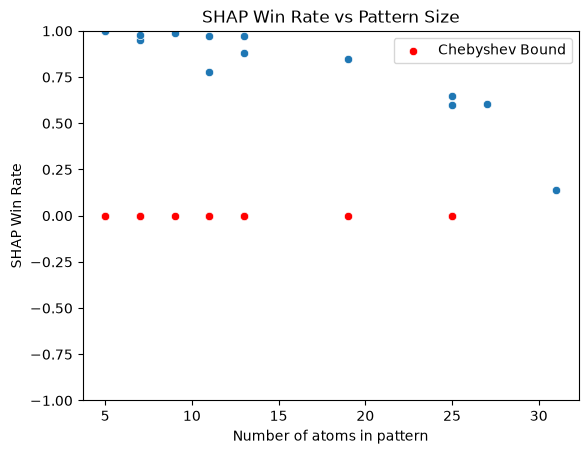

In [8]:
sns.scatterplot(
    x=pattern_sizes,
    y=winrates)

chebyshev_winrate_bounds = [1 - calculate_chebyshev_bound(size, 100) for size in pattern_sizes]
sns.scatterplot(
    x=pattern_sizes,
    y=chebyshev_winrate_bounds,
    label="Chebyshev Bound",
    color='red')

plt.xlabel("Number of atoms in pattern")
plt.ylim(-1, 1)
plt.ylabel("SHAP Win Rate")
plt.title("SHAP Win Rate vs Pattern Size")
plt.show()

In [24]:
explanations = torch.load(
    "artifacts/explainability_method_tester/R2-2026-07-21-18-56-08/MoleculeCDetector/SHAP Sampling_node_attrs_positive.pt")
explanations = [torch.sum(torch.abs(explanation), dim=1) for explanation in explanations]

In [25]:
molecules = pd.read_csv(
    "artifacts/explainability_method_tester/R2-2026-07-21-18-56-08/MoleculeCDetector/positive_explainability_results.csv")[
    "SMILES"].tolist()

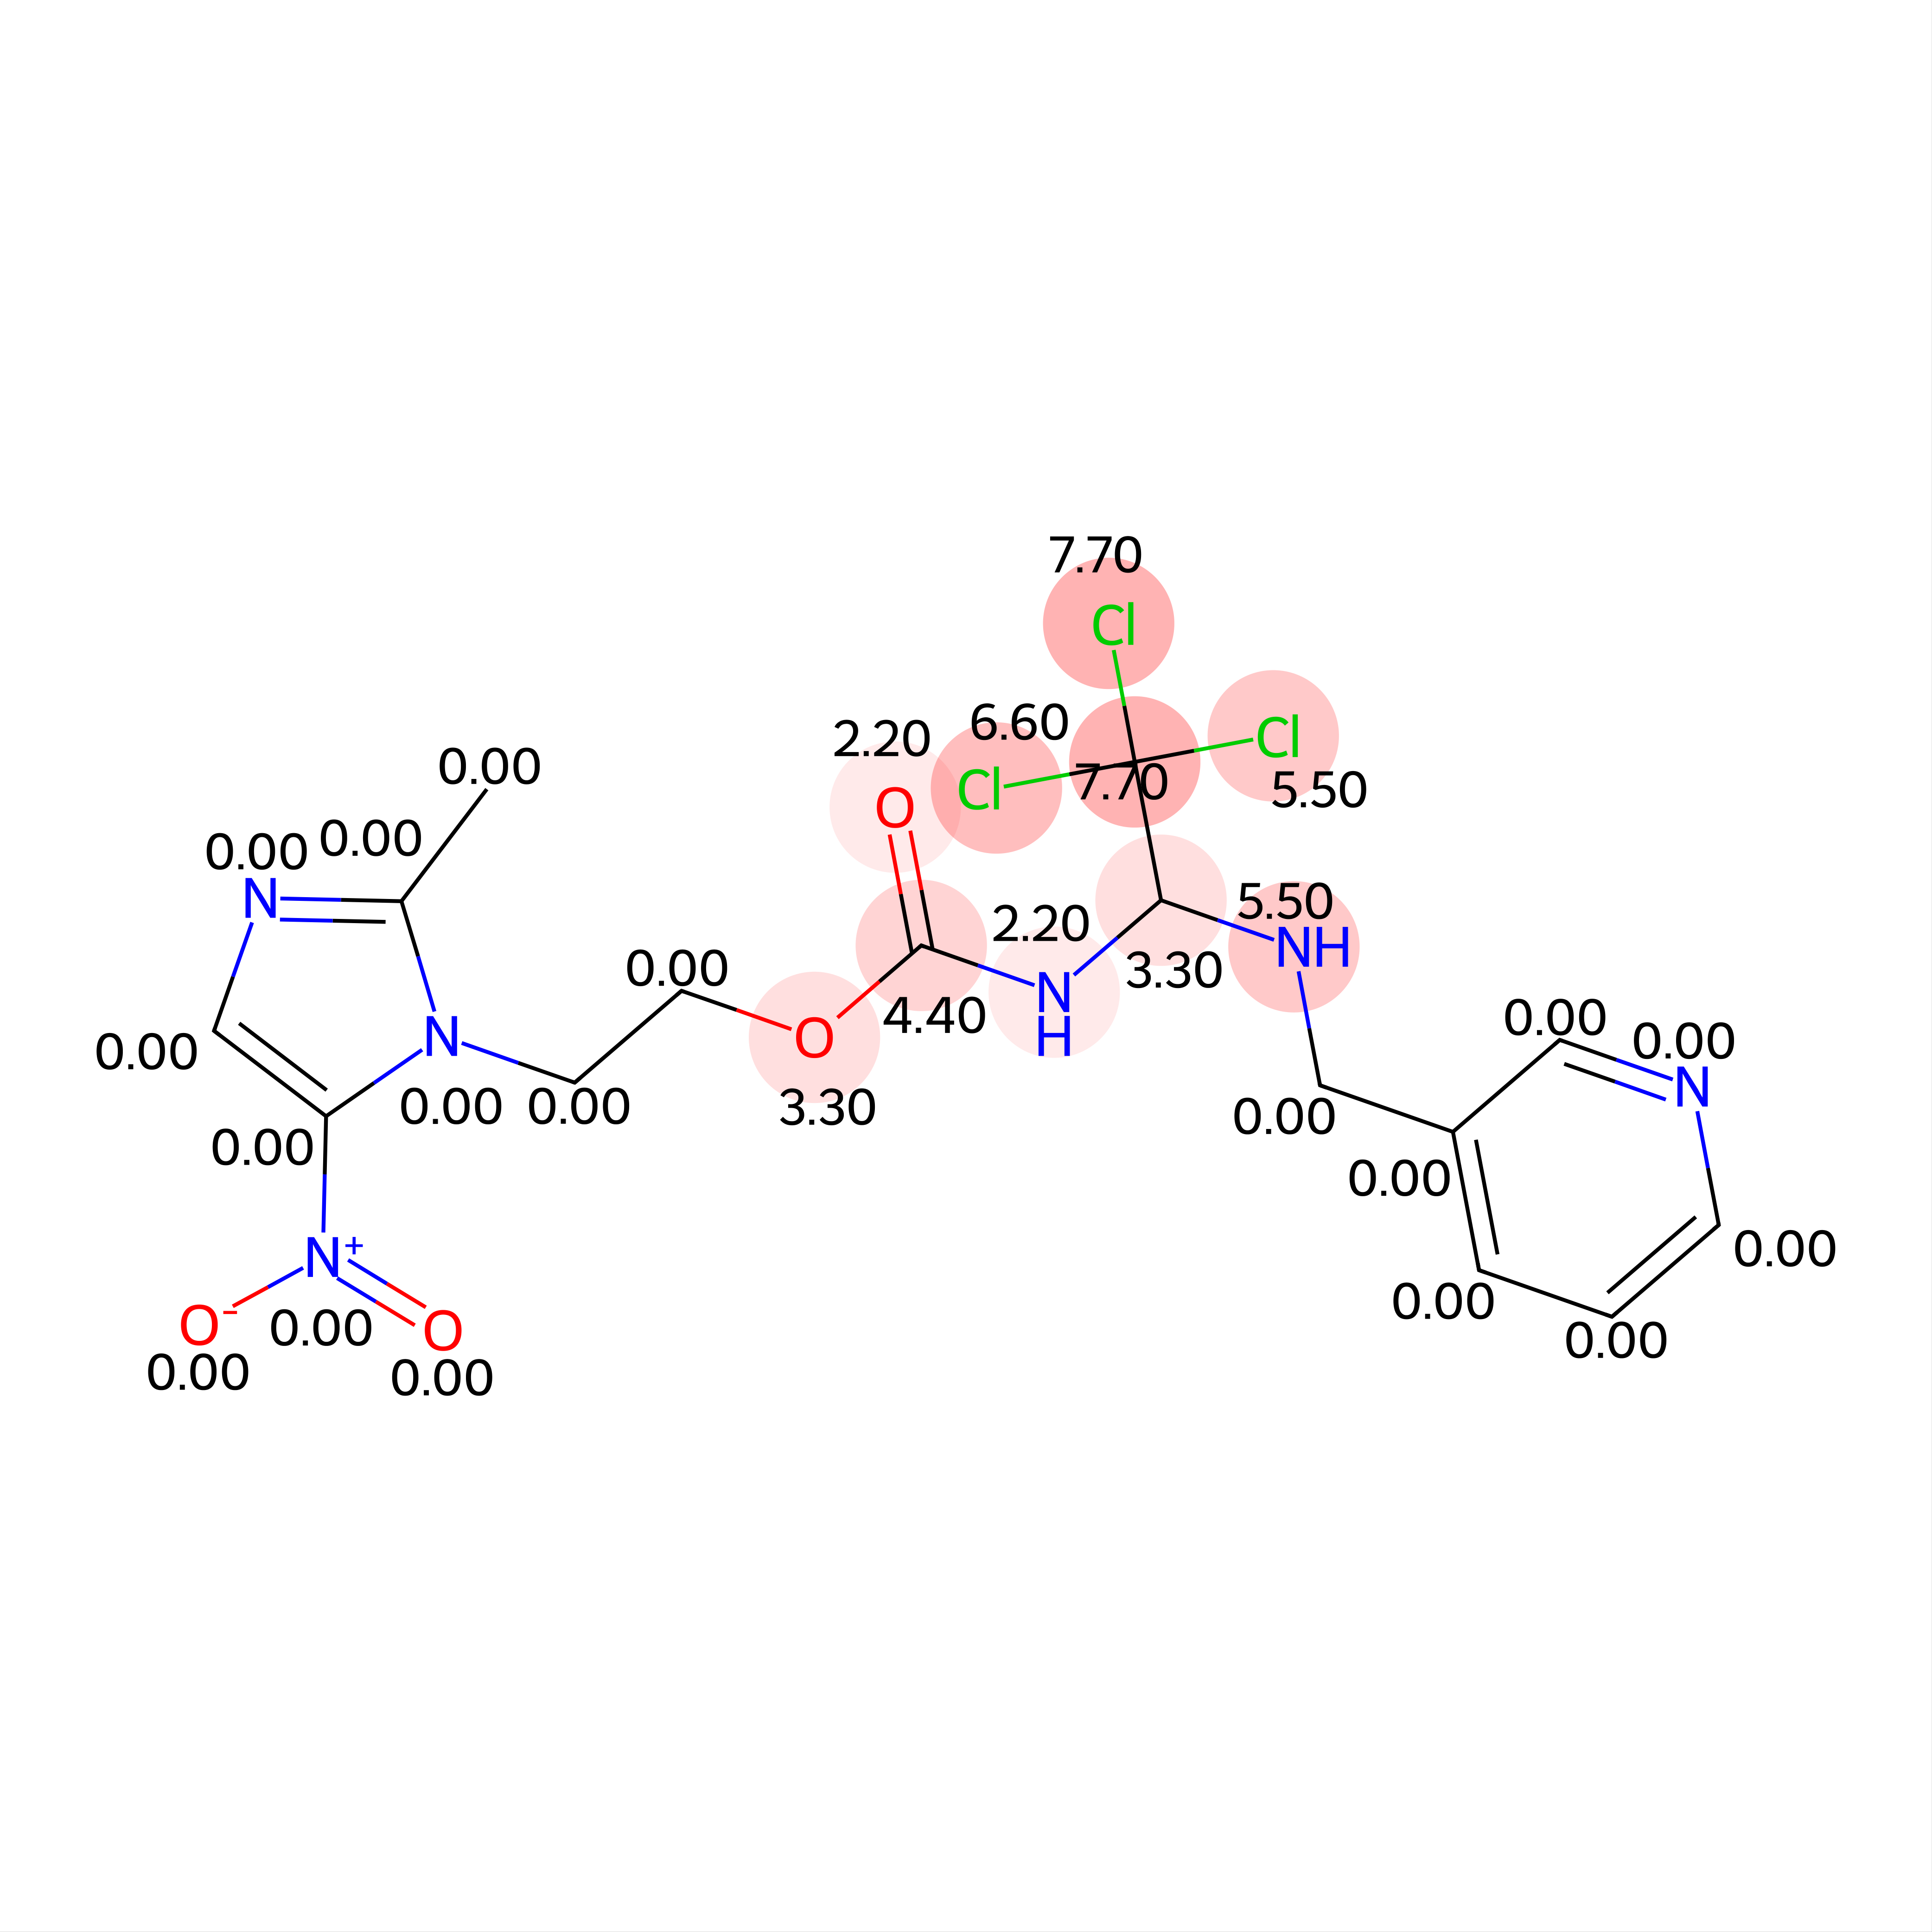

In [26]:
m1 = Chem.MolFromSmiles(molecules[0])

visualize_atom_importance_from_mol(
    m1, explanations[0].detach().numpy().tolist(),
    length=1000,
)